# Config and BPE Tokenizer

In [2]:
from config import ModelConfig

model_cfg = ModelConfig(
    name="BaseFromPaper",
    d_vocab=32_000,
    context_len=24,
    d_k=64,
    d_v=64,
    d_model=64,
    h=8,
    N=6,
    dropout_rate=0.1,
)

In [3]:
%env GLOG_minloglevel=2
from tokenizer import TokenizerBPE

tokenizer = TokenizerBPE(name=f"{model_cfg.d_vocab//1_000}k_shared", vocab_size=model_cfg.d_vocab)

env: GLOG_minloglevel=2


In [4]:
in_en = "some input text"
out_en = tokenizer.encode(in_en)
tokenizer.decode(out_en) == in_en

True

In [5]:
in_pl = "jakiś tekst wejściowy"
out_pl = tokenizer.encode(in_pl)
tokenizer.decode(out_pl) == in_pl

True

# Defining Model

In [6]:
import torch
from model import TransformerSeq2Seq

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [7]:
translate_model = TransformerSeq2Seq(model_cfg)

In [8]:
from config import TrainConfig

eval_every_n = 1

train_cfg = TrainConfig(
    epochs=8,
    batch_size=384,
    beta1=0.9,
    beta2=0.98,
    eps=1e-9,
    lr_factor=model_cfg.d_model ** -0.5,
    lr_warmup_steps=1000,
    label_smoothing_eps=0.1,
    eval_every_epochs=eval_every_n,
    eval_max_batches=10,
)

In [9]:
from dataloader import TranslationDataset

start_id=1
end_id=2
pad_id=3

train_dataset = TranslationDataset(
    en_path="./opus100/opus.en-pl-train.en",
    pl_path="./opus100/opus.en-pl-train.pl",
    sp_model=tokenizer._sp,
    start_id=start_id,
    end_id=end_id,
    pad_id=pad_id,
    context_len=model_cfg.context_len,
)

validate_dataset = TranslationDataset(
    en_path="./opus100/opus.en-pl-dev.en",
    pl_path="./opus100/opus.en-pl-dev.pl",
    sp_model=tokenizer._sp,
    start_id=start_id,
    end_id=end_id,
    pad_id=pad_id,
    context_len=model_cfg.context_len,
)

In [10]:
from train import run_training

train_loss, valid_loss = run_training(
    translate_model,
    train_cfg,
    train_dataset,
    validate_dataset,
    pad_id,
    DEVICE,
    max_batch_per_epoch=None,
)

Epoch 1/8: 100%|██████████| 2605/2605 [12:07<00:00,  3.58it/s, loss=4.9260, lr=2.45e-03]


epoch 0: train_loss=5.7840 valid_loss=3.9529


Epoch 2/8: 100%|██████████| 2605/2605 [12:51<00:00,  3.38it/s, loss=4.4114, lr=1.73e-03]


epoch 1: train_loss=4.5861 valid_loss=3.4725


Epoch 3/8: 100%|██████████| 2605/2605 [12:06<00:00,  3.59it/s, loss=4.3694, lr=1.41e-03]


...

epoch 5: train_loss=4.1556 valid_loss=3.1235


Epoch 7/8: 100%|██████████| 2605/2605 [13:54<00:00,  3.12it/s, loss=3.8218, lr=9.26e-04]


epoch 6: train_loss=4.1265 valid_loss=3.1035


Epoch 8/8: 100%|██████████| 2605/2605 [13:30<00:00,  3.21it/s, loss=4.1426, lr=8.66e-04]


epoch 7: train_loss=4.1047 valid_loss=3.0798


In [11]:
# torch.save(translate_model.state_dict, ".")

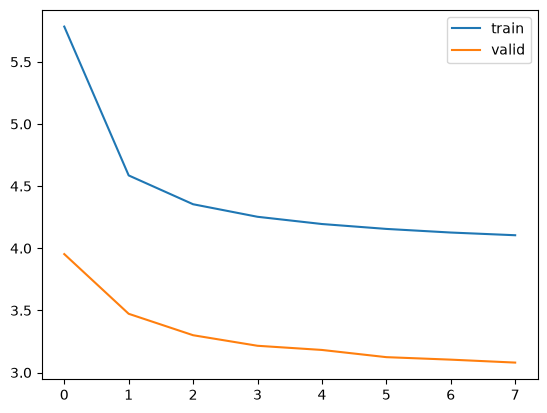

In [12]:
import matplotlib.pyplot as plt

train_x = [epoch for epoch, loss in train_loss]
train_y = [loss for epoch, loss in train_loss]

valid_x = [epoch for epoch, loss in valid_loss]
valid_y = [loss for epoch, loss in valid_loss]

plt.plot(train_x, train_y, label="train")
plt.plot(valid_x, valid_y, label="valid")

plt.legend()
plt.show()

In [ ]:
import torch


@torch.no_grad()
def translate(
    text: str,
    model,
    sp_model,
    start_id: int,
    end_id: int,
    pad_id: int,
    context_len: int,
    device: str,
) -> str:
    model.eval()

    src_ids = sp_model.encode(text, out_type=int)[:context_len]
    src = torch.tensor([src_ids], device=device)
    src_pad_mask = torch.zeros_like(src, dtype=torch.bool)

    # start dekodowania od <bos>
    decoder_input = torch.tensor([[start_id]], device=device)  # (1, 1)

    for _ in range(context_len - 1):
        tgt_pad_mask = torch.zeros_like(decoder_input, dtype=torch.bool)

        logits = model(
            src, decoder_input,
            src_pad_mask=src_pad_mask,
            tgt_pad_mask=tgt_pad_mask,
        )
        next_token = logits[0, -1].argmax(dim=-1).item()

        decoder_input = torch.cat(
            [decoder_input, torch.tensor([[next_token]], device=device)], dim=1
        )

        if next_token == end_id:
            break

    ids = decoder_input[0, 1:].tolist()
    if ids and ids[-1] == end_id:
        ids = ids[:-1]

    return sp_model.decode(ids)

In [15]:
translate(
    "I love cats",
    translate_model,
    tokenizer._sp,
    start_id,
    end_id,
    pad_id,
    model_cfg.context_len,
    DEVICE,
)

'Uwielbiam koty.'

### CORRECT!

In [16]:
import random

idx = random.randrange(len(validate_dataset))
en_sentence = validate_dataset.en_lines[idx]
pl_reference = validate_dataset.pl_lines[idx]

translation = translate(
    en_sentence, translate_model, tokenizer._sp,
    start_id, end_id, pad_id, model_cfg.context_len, DEVICE,
)

print(f"EN:  {en_sentence}")
print(f"PL (model):  {translation}")
print(f"PL (ref):    {pl_reference}")

EN:  Take the breeches from enemy rifles.
PL (model):  Weź łajki z gronów wroga.
PL (ref):    Weźcie zamki z ich karabinów.
